#IncodeVision                              
Name of Student: Uday Pravin Patil


# **Import Libraries**

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# **Load Dataset**

In [46]:
df = pd.read_csv('/content/Advertising.csv')

df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


# **Data Preprocessing**

In [47]:
# Drop unnecessary column if exists
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# Check missing values
print(df.isnull().sum())

# Dataset info
df.info()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


# **Exploratory Data Analysis**

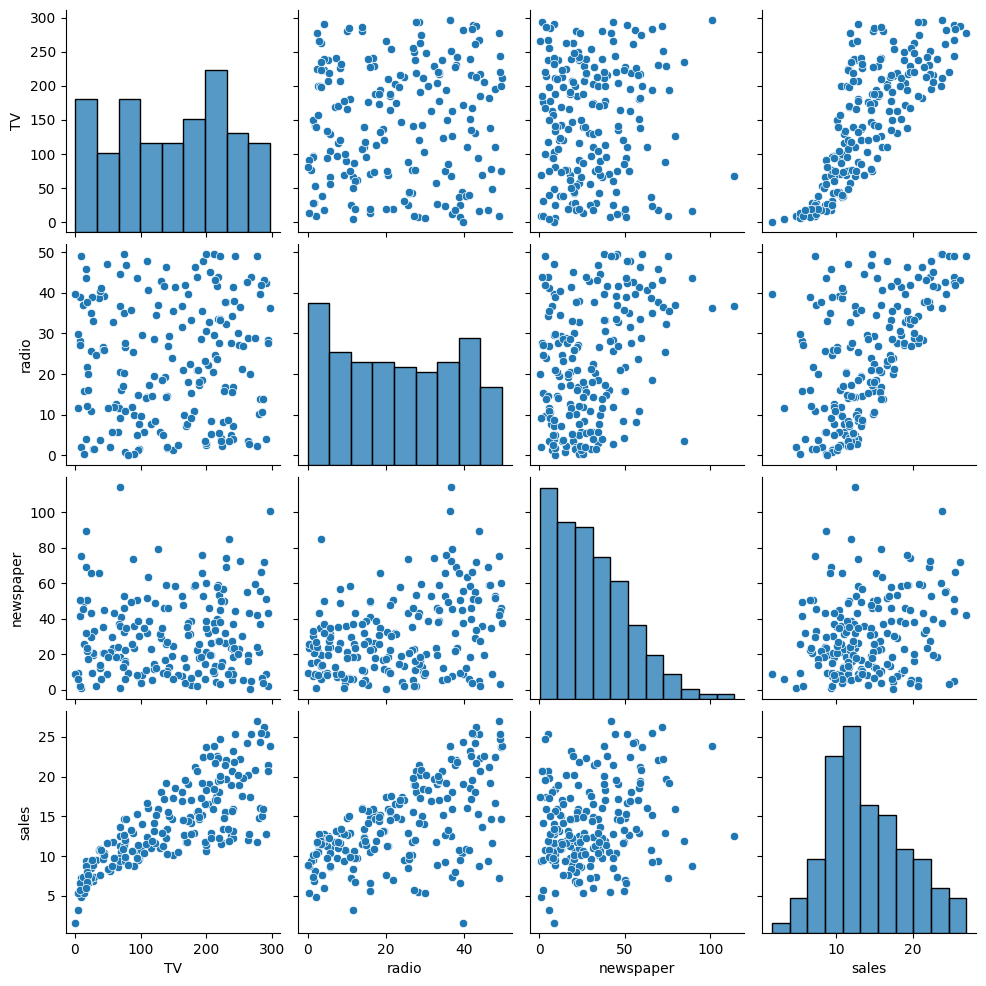

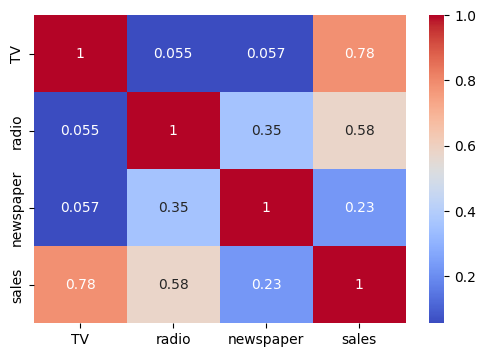

In [48]:
sns.pairplot(df)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

# **Define Features & Target**

In [49]:
X = df[['TV', 'radio', 'newspaper']]
y = df['sales']

# **Train-Test Split**

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **TrainModels**                           
Linear Regression

In [51]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

Decision Tree

In [52]:
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Random Forest (Best One)

In [53]:
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# **Evaluation Function**

In [54]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"{model_name} Performance:")
    print("R2 Score:", r2_score(y_test, y_pred))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("-"*40)

# **Evaluate All Models**

In [55]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression Performance:
R2 Score: 0.899438024100912
MAE: 1.4607567168117603
RMSE: 1.78159966153345
----------------------------------------
Decision Tree Performance:
R2 Score: 0.9489601845480602
MAE: 0.9349999999999999
RMSE: 1.2692517480783707
----------------------------------------
Random Forest Performance:
R2 Score: 0.9823294883840659
MAE: 0.6315000000000002
RMSE: 0.7468231718419042
----------------------------------------


# **Visualization**

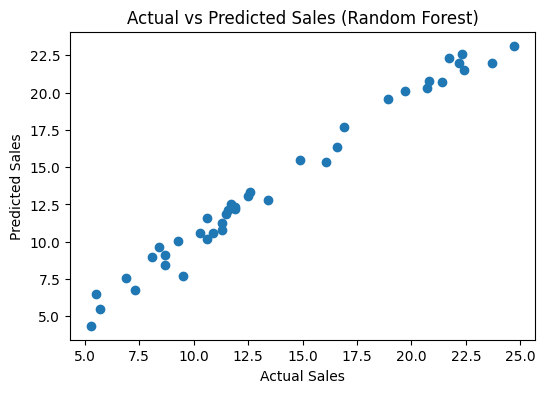

In [56]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

# **Feature Importance**

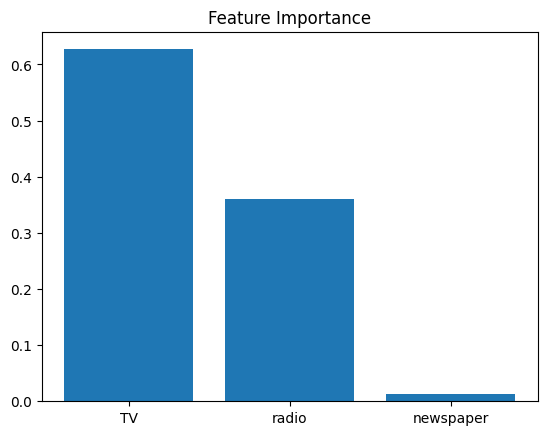

In [57]:
importance = rf.feature_importances_
features = X.columns

plt.bar(features, importance)
plt.title("Feature Importance")
plt.show()

# **Predict New Data**

In [58]:
# Example prediction
new_data = np.array([[150, 20, 10]])  # TV, Radio, Newspaper
prediction = rf.predict(new_data)

print("Predicted Sales:", prediction[0])

Predicted Sales: 14.206000000000008


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
